# Notebook 04: Seeded Model Evaluation

This notebook evaluates the seeded models produced by `03_model_training_seeded_fixed_split.ipynb`.

Main purpose:

- load predictions from all seeds,
- calculate performance metrics for every model and every seed,
- summarize results using mean ± standard deviation,
- compare stability across seeds,
- save report-ready tables and plots.

The train/test split remains fixed. The stability analysis here measures how model performance changes when only the model random seed changes.

### Cell 1: Imports

In [2]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


def make_json_serializable(value):
    """Convert NumPy/Pandas objects to safe Python types before saving JSON."""
    if isinstance(value, dict):
        return {
            str(make_json_serializable(key)): make_json_serializable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple, set)):
        return [make_json_serializable(item) for item in value]

    if isinstance(value, np.ndarray):
        return make_json_serializable(value.tolist())

    if isinstance(value, pd.DataFrame):
        return make_json_serializable(value.to_dict(orient="records"))

    if isinstance(value, pd.Series):
        return make_json_serializable(value.tolist())

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        if np.isnan(value):
            return None
        return float(value)

    if isinstance(value, float):
        if math.isnan(value):
            return None
        return value

    return value


def save_json(payload, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(
            make_json_serializable(payload),
            file,
            indent=4,
            ensure_ascii=False
        )


### Cell 2: Project paths and configuration

In [3]:
def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists() or (current_path / "results").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists() or (parent / "results").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TRAINING_RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
EVALUATION_RESULTS_DIR = PROJECT_ROOT / "results" / "04_model_evaluation"
PLOTS_DIR = PROJECT_ROOT / "plots" / "04_model_evaluation"

EVALUATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_MODEL_NAMES = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "mlp"
]

DEFAULT_SEEDS = list(range(1, 11))

print(f"Project root: {PROJECT_ROOT}")
print(f"Training results directory: {TRAINING_RESULTS_DIR}")
print(f"Evaluation results directory: {EVALUATION_RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: G:\Programming\xai
Training results directory: G:\Programming\xai\results\03_model_training
Evaluation results directory: G:\Programming\xai\results\04_model_evaluation
Plots directory: G:\Programming\xai\plots\04_model_evaluation


### Cell 3: Load seeded training summary

In [4]:
def load_training_summary(results_dir: Path) -> dict:
    summary_paths = [
        results_dir / "training_summary_seeded.json",
        results_dir / "training_summary.json"
    ]

    for path in summary_paths:
        if path.exists():
            with open(path, "r", encoding="utf-8") as file:
                summary = json.load(file)

            print(f"Loaded training summary: {path}")
            return summary

    print("No training summary JSON found. Using default seeds and model names.")
    return {}


training_summary = load_training_summary(TRAINING_RESULTS_DIR)

SEEDS = training_summary.get("seeds", DEFAULT_SEEDS)
SEEDS = [int(seed) for seed in SEEDS]

PRIMARY_SEED = int(training_summary.get("primary_seed", SEEDS[0]))

MODEL_NAMES = training_summary.get("models", DEFAULT_MODEL_NAMES)
MODEL_NAMES = list(MODEL_NAMES)

print(f"Seeds: {SEEDS}")
print(f"Primary seed: {PRIMARY_SEED}")
print(f"Models: {MODEL_NAMES}")

Loaded training summary: G:\Programming\xai\results\03_model_training\training_summary_seeded.json
Seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Primary seed: 1
Models: ['logistic_regression', 'decision_tree', 'random_forest', 'mlp']


### Cell 4: Load all seeded predictions

In [5]:
def convert_label_columns(predictions_df: pd.DataFrame) -> pd.DataFrame:
    predictions_df = predictions_df.copy()

    for column in ["true_label", "predicted_label"]:
        converted = pd.to_numeric(predictions_df[column], errors="coerce")

        if converted.notna().all():
            predictions_df[column] = converted.astype(int)

    return predictions_df


def load_seeded_predictions(results_dir: Path, seeds: list[int], model_names: list[str]) -> pd.DataFrame:
    combined_path = results_dir / "all_seed_predictions.csv"

    if combined_path.exists():
        predictions_df = pd.read_csv(combined_path)
        print(f"Loaded combined prediction file: {combined_path}")

    else:
        print("Combined prediction file not found. Loading per-seed prediction files.")

        prediction_frames = []

        for seed in seeds:
            seed_dir = results_dir / f"seed_{seed}"

            for model_name in model_names:
                file_path = seed_dir / f"{model_name}_predictions.csv"

                if not file_path.exists():
                    raise FileNotFoundError(f"Missing prediction file: {file_path}")

                model_predictions = pd.read_csv(file_path)

                if "seed" not in model_predictions.columns:
                    model_predictions.insert(0, "seed", seed)

                if "model_name" not in model_predictions.columns:
                    model_predictions.insert(1, "model_name", model_name)

                prediction_frames.append(model_predictions)

        predictions_df = pd.concat(prediction_frames, ignore_index=True)

    required_columns = {
        "seed",
        "model_name",
        "sample_id",
        "true_label",
        "predicted_label"
    }

    missing_columns = required_columns.difference(predictions_df.columns)

    if missing_columns:
        raise ValueError(
            f"Prediction file is missing required columns: {sorted(missing_columns)}"
        )

    predictions_df = convert_label_columns(predictions_df)
    predictions_df["seed"] = predictions_df["seed"].astype(int)

    predictions_df = predictions_df.sort_values(
        by=["seed", "model_name", "sample_id"]
    ).reset_index(drop=True)

    return predictions_df


predictions_df = load_seeded_predictions(
    results_dir=TRAINING_RESULTS_DIR,
    seeds=SEEDS,
    model_names=MODEL_NAMES
)

print(f"Prediction rows: {len(predictions_df)}")
print(f"Seeds found: {sorted(predictions_df['seed'].unique())}")
print(f"Models found: {sorted(predictions_df['model_name'].unique())}")

predictions_df.head()

Loaded combined prediction file: G:\Programming\xai\results\03_model_training\all_seed_predictions.csv
Prediction rows: 108360
Seeds found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Models found: ['decision_tree', 'logistic_regression', 'mlp', 'random_forest']


,seed,model_name,sample_id,true_label,predicted_label
0,1,decision_tree,10,5,5
1,1,decision_tree,11,5,5
2,1,decision_tree,15,5,5
3,1,decision_tree,22,5,5
4,1,decision_tree,23,5,6


### Cell 5: Check prediction coverage

In [6]:
coverage_df = (
    predictions_df
    .groupby(["seed", "model_name"])
    .agg(
        n_samples=("sample_id", "count"),
        n_unique_samples=("sample_id", "nunique")
    )
    .reset_index()
    .sort_values(["seed", "model_name"])
)

coverage_path = EVALUATION_RESULTS_DIR / "prediction_coverage_all_seeds.csv"
coverage_df.to_csv(coverage_path, index=False)

expected_rows = len(SEEDS) * len(MODEL_NAMES)
actual_rows = len(coverage_df)

if actual_rows != expected_rows:
    print(
        f"Warning: expected {expected_rows} seed-model combinations, "
        f"but found {actual_rows}."
    )
else:
    print("Prediction coverage looks complete.")

print(f"Saved: {coverage_path}")

coverage_df.head(12)

Prediction coverage looks complete.
Saved: G:\Programming\xai\results\04_model_evaluation\prediction_coverage_all_seeds.csv


,seed,model_name,n_samples,n_unique_samples
0,1,decision_tree,2709,2709
1,1,logistic_regression,2709,2709
2,1,mlp,2709,2709
3,1,random_forest,2709,2709
4,2,decision_tree,2709,2709
5,2,logistic_regression,2709,2709
6,2,mlp,2709,2709
7,2,random_forest,2709,2709
8,3,decision_tree,2709,2709
9,3,logistic_regression,2709,2709


### Cell 6: Calculate metrics for every model and every seed

In [7]:
def calculate_metrics_for_group(seed: int, model_name: str, group_df: pd.DataFrame) -> dict:
    y_true = group_df["true_label"]
    y_pred = group_df["predicted_label"]

    return {
        "seed": int(seed),
        "model_name": model_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0))
    }


metric_rows = []

for (seed, model_name), group_df in predictions_df.groupby(["seed", "model_name"]):
    metric_rows.append(
        calculate_metrics_for_group(
            seed=seed,
            model_name=model_name,
            group_df=group_df
        )
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df = metrics_df.sort_values(["model_name", "seed"]).reset_index(drop=True)

metrics_all_seeds_path = EVALUATION_RESULTS_DIR / "evaluation_metrics_all_seeds.csv"
metrics_json_path = EVALUATION_RESULTS_DIR / "evaluation_metrics_all_seeds.json"

metrics_df.to_csv(metrics_all_seeds_path, index=False)
save_json(metrics_df, metrics_json_path)

print(f"Saved CSV: {metrics_all_seeds_path}")
print(f"Saved JSON: {metrics_json_path}")

metrics_df.head(12)


Saved CSV: G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_all_seeds.csv
Saved JSON: G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_all_seeds.json


,seed,model_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,1,decision_tree,0.897010,0.910649,0.912425,0.911434,0.896881
1,2,decision_tree,0.895533,0.910699,0.911309,0.910863,0.895245
2,3,decision_tree,0.894795,0.910368,0.911578,0.910924,0.894677
3,4,decision_tree,0.897010,0.912000,0.913084,0.912404,0.896559
4,5,decision_tree,0.896641,0.911548,0.912306,0.911826,0.896496
5,6,decision_tree,0.895533,0.910431,0.911149,0.910682,0.895276
6,7,decision_tree,0.895164,0.909547,0.911307,0.910350,0.895056
7,8,decision_tree,0.898487,0.913305,0.914184,0.913663,0.898289
8,9,decision_tree,0.899963,0.913602,0.914281,0.913839,0.899708
9,10,decision_tree,0.894795,0.911333,0.911674,0.911388,0.894621


### Cell 7: Save primary-seed metrics for backward compatibility

In [8]:
primary_metrics_df = (
    metrics_df[metrics_df["seed"] == PRIMARY_SEED]
    .copy()
    .sort_values("model_name")
    .reset_index(drop=True)
)

primary_metrics_path = EVALUATION_RESULTS_DIR / "evaluation_metrics_primary_seed.csv"
legacy_metrics_path = EVALUATION_RESULTS_DIR / "evaluation_metrics.csv"

primary_metrics_df.to_csv(primary_metrics_path, index=False)
primary_metrics_df.to_csv(legacy_metrics_path, index=False)

primary_metrics_json_path = EVALUATION_RESULTS_DIR / "evaluation_metrics_primary_seed.json"
save_json(primary_metrics_df, primary_metrics_json_path)

print(f"Saved: {primary_metrics_path}")
print(f"Saved legacy-compatible file: {legacy_metrics_path}")

primary_metrics_df


Saved: G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_primary_seed.csv
Saved legacy-compatible file: G:\Programming\xai\results\04_model_evaluation\evaluation_metrics.csv


,seed,model_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,1,decision_tree,0.897010,0.910649,0.912425,0.911434,0.896881
1,1,logistic_regression,0.919158,0.930725,0.930049,0.930237,0.919290
2,1,mlp,0.926172,0.936423,0.936029,0.936089,0.926327
3,1,random_forest,0.917313,0.930248,0.928142,0.929091,0.917221


### Cell 8: Summarize performance as mean ± standard deviation

In [9]:
metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]


def flatten_columns(columns) -> list[str]:
    flattened = []

    for column in columns:
        if isinstance(column, tuple):
            clean_parts = [str(part) for part in column if part]
            flattened.append("_".join(clean_parts))
        else:
            flattened.append(str(column))

    return flattened


summary_df = (
    metrics_df
    .groupby("model_name")
    .agg({
        metric: ["mean", "std", "min", "max"]
        for metric in metric_columns
    })
    .reset_index()
)

summary_df.columns = flatten_columns(summary_df.columns)

summary_df = summary_df.sort_values(
    by="f1_macro_mean",
    ascending=False
).reset_index(drop=True)

summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary_mean_std.csv"
summary_json_path = EVALUATION_RESULTS_DIR / "evaluation_summary_mean_std.json"

summary_df.to_csv(summary_path, index=False)
save_json(summary_df, summary_json_path)

print(f"Saved: {summary_path}")
print(f"Saved: {summary_json_path}")

summary_df


Saved: G:\Programming\xai\results\04_model_evaluation\evaluation_summary_mean_std.csv
Saved: G:\Programming\xai\results\04_model_evaluation\evaluation_summary_mean_std.json


,model_name,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,precision_macro_mean,precision_macro_std,precision_macro_min,precision_macro_max,recall_macro_mean,...,recall_macro_min,recall_macro_max,f1_macro_mean,f1_macro_std,f1_macro_min,f1_macro_max,f1_weighted_mean,f1_weighted_std,f1_weighted_min,f1_weighted_max
0,mlp,0.924216,0.003242,0.916574,0.927649,0.935156,0.002383,0.929258,0.938024,0.934041,...,0.929051,0.937896,0.934460,0.002526,0.928943,0.937940,0.924218,0.003219,0.916855,0.927581
1,logistic_regression,0.919158,0.000000,0.919158,0.919158,0.930725,0.000000,0.930725,0.930725,0.930049,...,0.930049,0.930049,0.930237,0.000000,0.930237,0.930237,0.919290,0.000000,0.919290,0.919290
2,random_forest,0.918346,0.001125,0.916205,0.919897,0.931108,0.000974,0.928920,0.932359,0.929101,...,0.927276,0.930646,0.930007,0.000963,0.927974,0.931420,0.918234,0.001127,0.916049,0.919774
3,decision_tree,0.896493,0.001698,0.894795,0.899963,0.911348,0.001305,0.909547,0.913602,0.912330,...,0.911149,0.914281,0.911737,0.001214,0.910350,0.913839,0.896281,0.001672,0.894621,0.899708


### Cell 9: Identify best and most stable models

In [10]:
best_accuracy_model = summary_df.loc[
    summary_df["accuracy_mean"].idxmax(),
    "model_name"
]

best_f1_model = summary_df.loc[
    summary_df["f1_macro_mean"].idxmax(),
    "model_name"
]

most_stable_accuracy_model = summary_df.loc[
    summary_df["accuracy_std"].idxmin(),
    "model_name"
]

most_stable_f1_model = summary_df.loc[
    summary_df["f1_macro_std"].idxmin(),
    "model_name"
]

least_stable_f1_model = summary_df.loc[
    summary_df["f1_macro_std"].idxmax(),
    "model_name"
]

best_single_run = metrics_df.loc[
    metrics_df["f1_macro"].idxmax()
].to_dict()

print(f"Best mean accuracy model: {best_accuracy_model}")
print(f"Best mean macro F1 model: {best_f1_model}")
print(f"Most stable accuracy model: {most_stable_accuracy_model}")
print(f"Most stable macro F1 model: {most_stable_f1_model}")
print(f"Least stable macro F1 model: {least_stable_f1_model}")
print(f"Best single run: seed={best_single_run['seed']}, model={best_single_run['model_name']}, f1_macro={best_single_run['f1_macro']:.4f}")

Best mean accuracy model: mlp
Best mean macro F1 model: mlp
Most stable accuracy model: logistic_regression
Most stable macro F1 model: logistic_regression
Least stable macro F1 model: mlp
Best single run: seed=4, model=mlp, f1_macro=0.9379


### Cell 10: Load class names

In [11]:
def load_class_id_to_name(data_processed_dir: Path, labels) -> dict:
    mapping_path = data_processed_dir / "label_mapping.json"
    fallback = {int(label): str(label) for label in labels}

    if not mapping_path.exists():
        print("Label mapping file not found. Using numeric class labels.")
        return fallback

    with open(mapping_path, "r", encoding="utf-8") as file:
        mapping = json.load(file)

    class_id_to_name = {}

    for key, value in mapping.items():
        key_as_int = None
        value_as_int = None

        try:
            key_as_int = int(key)
        except (TypeError, ValueError):
            pass

        try:
            value_as_int = int(value)
        except (TypeError, ValueError):
            pass

        if key_as_int is not None and isinstance(value, str):
            class_id_to_name[int(key_as_int)] = value

        elif value_as_int is not None and isinstance(key, str):
            class_id_to_name[int(value_as_int)] = key

    if not class_id_to_name:
        print("Could not parse label mapping. Using numeric class labels.")
        return fallback

    for label in labels:
        class_id_to_name.setdefault(int(label), str(label))

    return class_id_to_name


class_labels = sorted(
    set(predictions_df["true_label"].unique()).union(
        set(predictions_df["predicted_label"].unique())
    )
)
class_labels = [int(label) for label in class_labels]

class_id_to_name = load_class_id_to_name(DATA_PROCESSED_DIR, class_labels)
class_names = [class_id_to_name[int(label)] for label in class_labels]

print("Class labels:")
for label, name in zip(class_labels, class_names):
    print(f"  {label}: {name}")


Class labels:
  0: BARBUNYA
  1: BOMBAY
  2: CALI
  3: DERMASON
  4: HOROZ
  5: SEKER
  6: SIRA


### Cell 11: Classification reports for all seeds

In [12]:
classification_reports = {}

for (seed, model_name), group_df in predictions_df.groupby(["seed", "model_name"]):
    y_true = group_df["true_label"]
    y_pred = group_df["predicted_label"]

    report = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    classification_reports[f"seed_{int(seed)}__{model_name}"] = report

reports_all_seeds_path = EVALUATION_RESULTS_DIR / "classification_reports_all_seeds.json"
save_json(classification_reports, reports_all_seeds_path)

primary_reports = {
    key.replace(f"seed_{PRIMARY_SEED}__", ""): value
    for key, value in classification_reports.items()
    if key.startswith(f"seed_{PRIMARY_SEED}__")
}

legacy_reports_path = EVALUATION_RESULTS_DIR / "classification_reports.json"
save_json(primary_reports, legacy_reports_path)

print(f"Saved: {reports_all_seeds_path}")
print(f"Saved primary-seed classification reports for compatibility: {legacy_reports_path}")


Saved: G:\Programming\xai\results\04_model_evaluation\classification_reports_all_seeds.json
Saved primary-seed classification reports for compatibility: G:\Programming\xai\results\04_model_evaluation\classification_reports.json


### Cell 12: Classwise performance across seeds

In [13]:
classwise_rows = []

for key, report in classification_reports.items():
    seed_part, model_name = key.split("__", maxsplit=1)
    seed = int(seed_part.replace("seed_", ""))

    for class_name in class_names:
        class_report = report[class_name]

        classwise_rows.append({
            "seed": seed,
            "model_name": model_name,
            "class_name": class_name,
            "precision": class_report["precision"],
            "recall": class_report["recall"],
            "f1_score": class_report["f1-score"],
            "support": class_report["support"]
        })

classwise_df = pd.DataFrame(classwise_rows)

classwise_path = EVALUATION_RESULTS_DIR / "classwise_performance_all_seeds.csv"
classwise_df.to_csv(classwise_path, index=False)

classwise_summary_df = (
    classwise_df
    .groupby(["model_name", "class_name"])
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_score_mean=("f1_score", "mean"),
        f1_score_std=("f1_score", "std"),
        support_mean=("support", "mean")
    )
    .reset_index()
    .sort_values(["model_name", "class_name"])
)

classwise_summary_path = EVALUATION_RESULTS_DIR / "classwise_performance_mean_std.csv"
classwise_summary_df.to_csv(classwise_summary_path, index=False)

print(f"Saved: {classwise_path}")
print(f"Saved: {classwise_summary_path}")

classwise_summary_df.head(14)

Saved: G:\Programming\xai\results\04_model_evaluation\classwise_performance_all_seeds.csv
Saved: G:\Programming\xai\results\04_model_evaluation\classwise_performance_mean_std.csv


,model_name,class_name,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std,support_mean
0,decision_tree,BARBUNYA,0.891775,0.006966,0.898113,0.005337,0.894910,0.004094,265.0
1,decision_tree,BOMBAY,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,104.0
2,decision_tree,CALI,0.902457,0.004500,0.919325,0.003839,0.910805,0.003148,326.0
3,decision_tree,DERMASON,0.888439,0.004942,0.896192,0.004850,0.892291,0.004041,709.0
4,decision_tree,HOROZ,0.952085,0.005489,0.928763,0.003640,0.940268,0.002949,372.0
5,decision_tree,SEKER,0.908962,0.004515,0.934236,0.003083,0.921417,0.002442,406.0
6,decision_tree,SIRA,0.835719,0.005571,0.809677,0.006697,0.822470,0.004297,527.0
7,logistic_regression,BARBUNYA,0.925490,0.000000,0.890566,0.000000,0.907692,0.000000,265.0
8,logistic_regression,BOMBAY,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,104.0
9,logistic_regression,CALI,0.910979,0.000000,0.941718,0.000000,0.926094,0.000000,326.0


### Cell 13: Confusion matrices for all seeds

In [14]:
def get_confusion_matrix(group_df: pd.DataFrame) -> list[list[int]]:
    matrix = confusion_matrix(
        group_df["true_label"],
        group_df["predicted_label"],
        labels=class_labels
    )

    return [[int(value) for value in row] for row in matrix.tolist()]


confusion_matrices = {}

for (seed, model_name), group_df in predictions_df.groupby(["seed", "model_name"]):
    confusion_matrices[f"seed_{int(seed)}__{model_name}"] = get_confusion_matrix(group_df)

confusion_matrix_payload = {
    "class_labels": [int(label) for label in class_labels],
    "class_names": [str(name) for name in class_names],
    "matrices": confusion_matrices
}

confusion_matrices_path = EVALUATION_RESULTS_DIR / "confusion_matrices_all_seeds.json"
save_json(confusion_matrix_payload, confusion_matrices_path)

primary_confusion_matrices = {
    key.replace(f"seed_{PRIMARY_SEED}__", ""): value
    for key, value in confusion_matrices.items()
    if key.startswith(f"seed_{PRIMARY_SEED}__")
}

legacy_confusion_matrix_path = EVALUATION_RESULTS_DIR / "confusion_matrices.json"
save_json(primary_confusion_matrices, legacy_confusion_matrix_path)

print(f"Saved: {confusion_matrices_path}")
print(f"Saved primary-seed confusion matrices for compatibility: {legacy_confusion_matrix_path}")


Saved: G:\Programming\xai\results\04_model_evaluation\confusion_matrices_all_seeds.json
Saved primary-seed confusion matrices for compatibility: G:\Programming\xai\results\04_model_evaluation\confusion_matrices.json


### Cell 14: Plot primary-seed confusion matrices

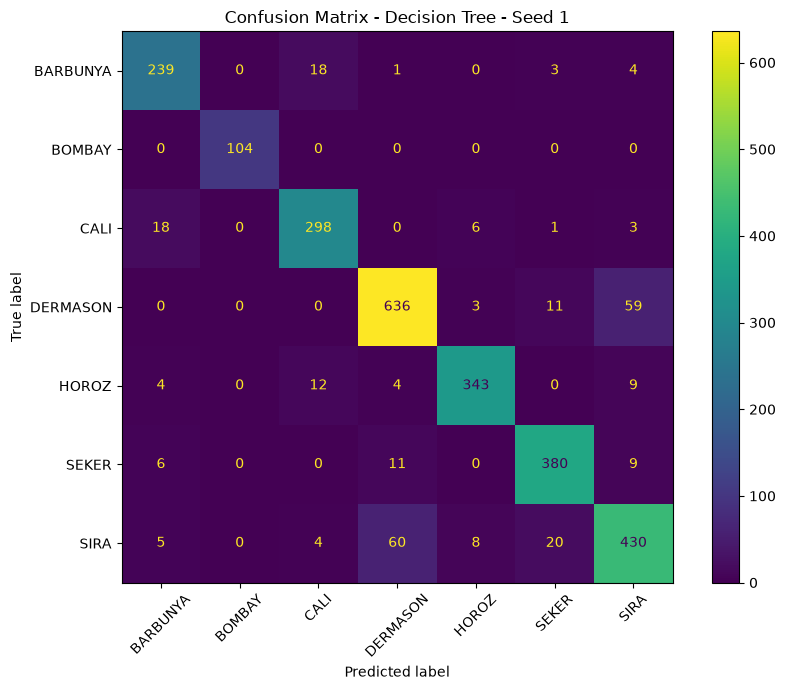

Saved: G:\Programming\xai\plots\04_model_evaluation\confusion_matrix_primary_seed_decision_tree.png


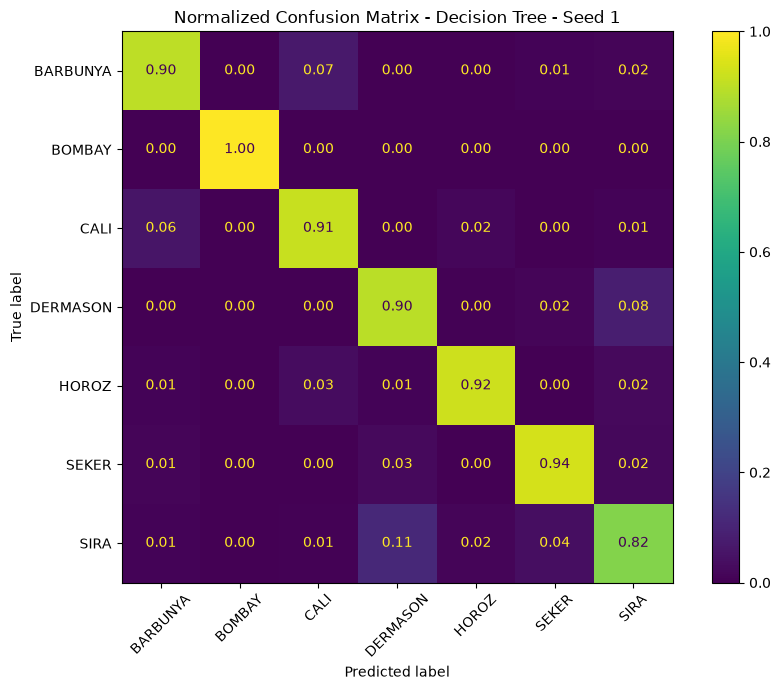

Saved: G:\Programming\xai\plots\04_model_evaluation\normalized_confusion_matrix_primary_seed_decision_tree.png


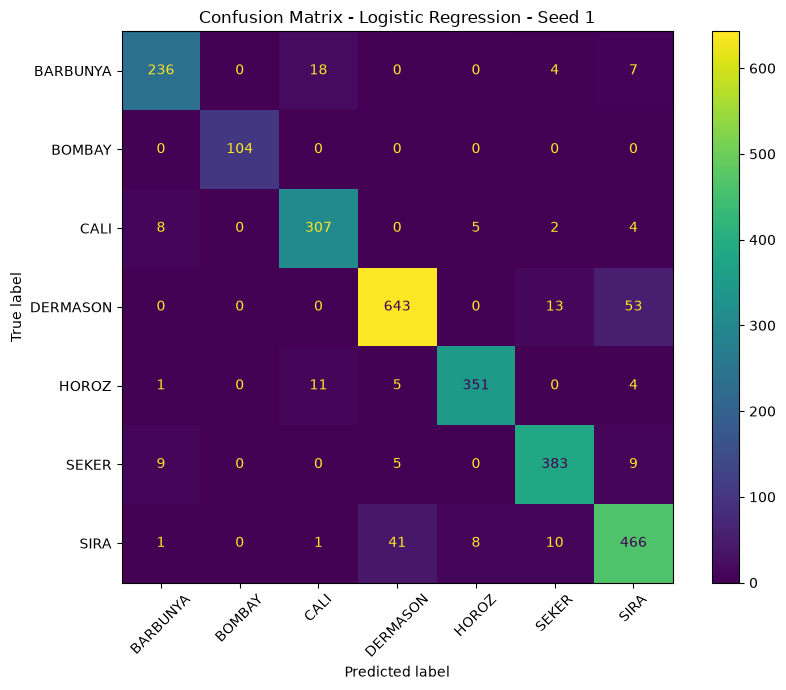

Saved: G:\Programming\xai\plots\04_model_evaluation\confusion_matrix_primary_seed_logistic_regression.png


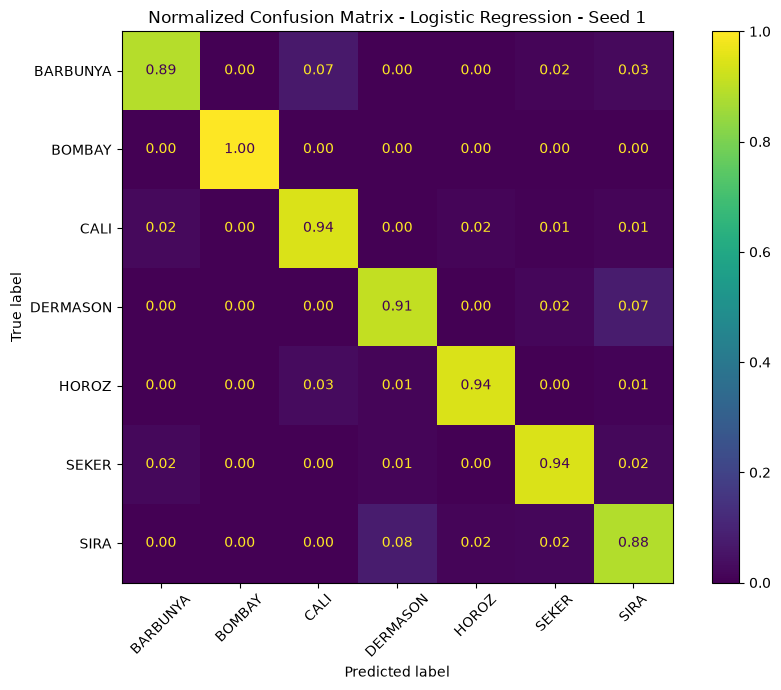

Saved: G:\Programming\xai\plots\04_model_evaluation\normalized_confusion_matrix_primary_seed_logistic_regression.png


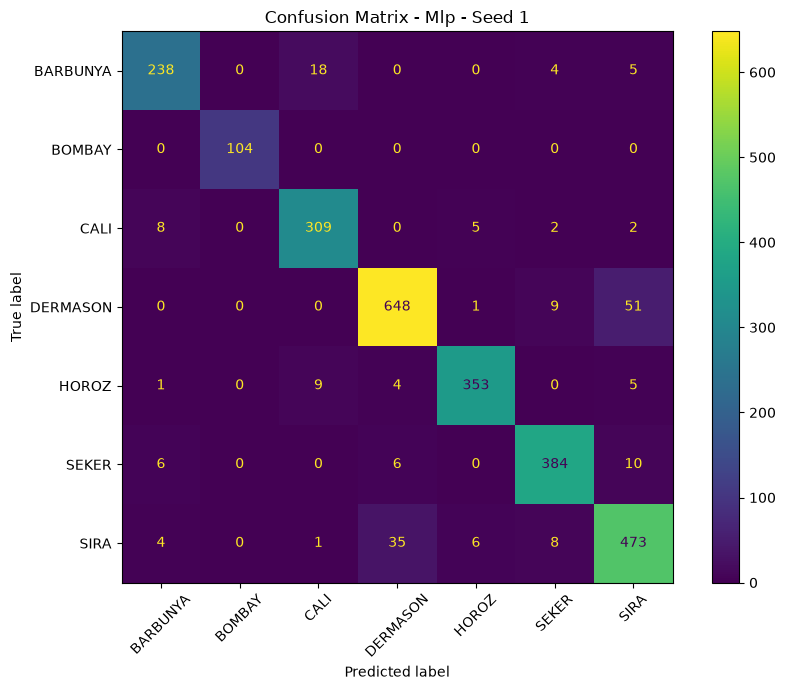

Saved: G:\Programming\xai\plots\04_model_evaluation\confusion_matrix_primary_seed_mlp.png


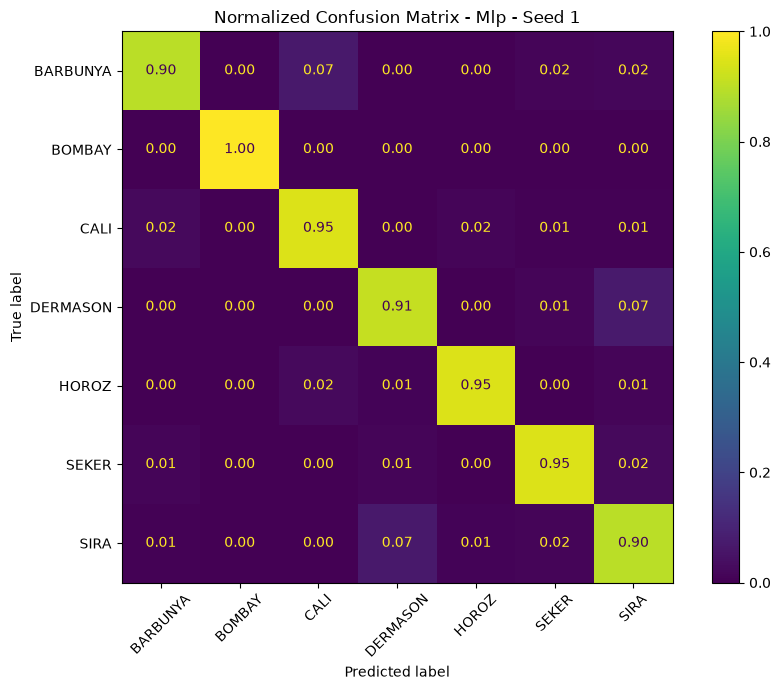

Saved: G:\Programming\xai\plots\04_model_evaluation\normalized_confusion_matrix_primary_seed_mlp.png


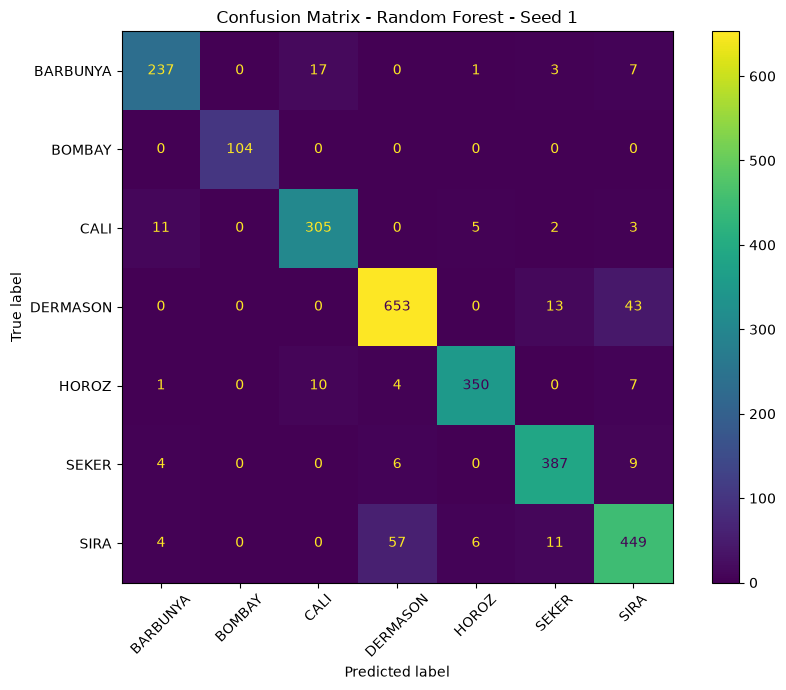

Saved: G:\Programming\xai\plots\04_model_evaluation\confusion_matrix_primary_seed_random_forest.png


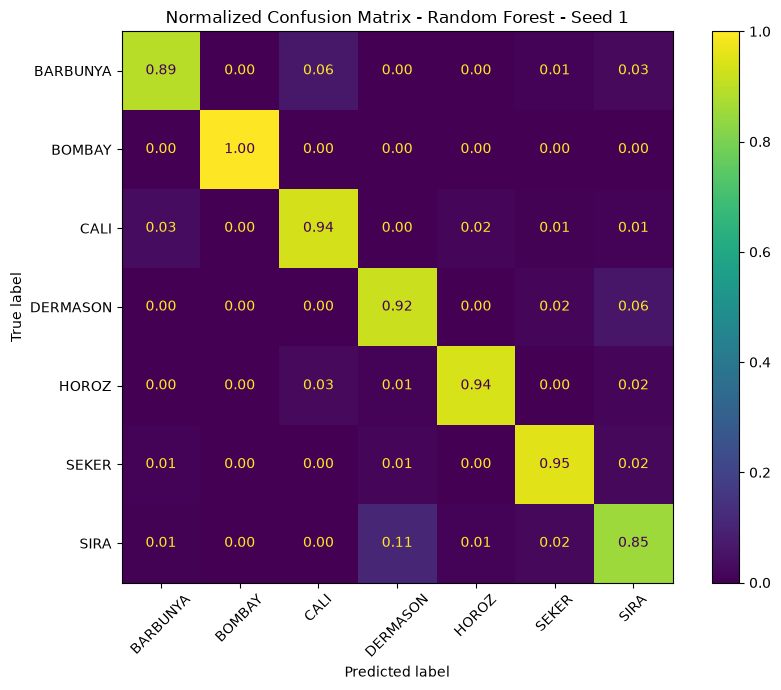

Saved: G:\Programming\xai\plots\04_model_evaluation\normalized_confusion_matrix_primary_seed_random_forest.png


In [15]:
def plot_confusion_matrix_from_predictions(
    group_df: pd.DataFrame,
    model_name: str,
    seed: int,
    output_path: Path,
    normalize=None,
    title_prefix: str = "Confusion Matrix"
):
    matrix = confusion_matrix(
        group_df["true_label"],
        group_df["predicted_label"],
        labels=class_labels,
        normalize=normalize
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    values_format = ".2f" if normalize else "d"

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names
    )

    display.plot(
        values_format=values_format,
        ax=ax,
        xticks_rotation=45
    )

    ax.set_title(
        f"{title_prefix} - {model_name.replace('_', ' ').title()} - Seed {seed}"
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {output_path}")


primary_predictions_df = predictions_df[predictions_df["seed"] == PRIMARY_SEED].copy()

for model_name, group_df in primary_predictions_df.groupby("model_name"):
    plot_path = PLOTS_DIR / f"confusion_matrix_primary_seed_{model_name}.png"

    plot_confusion_matrix_from_predictions(
        group_df=group_df,
        model_name=model_name,
        seed=PRIMARY_SEED,
        output_path=plot_path
    )

    normalized_plot_path = PLOTS_DIR / f"normalized_confusion_matrix_primary_seed_{model_name}.png"

    plot_confusion_matrix_from_predictions(
        group_df=group_df,
        model_name=model_name,
        seed=PRIMARY_SEED,
        output_path=normalized_plot_path,
        normalize="true",
        title_prefix="Normalized Confusion Matrix"
    )

### Cell 15: Plot performance trends across seeds

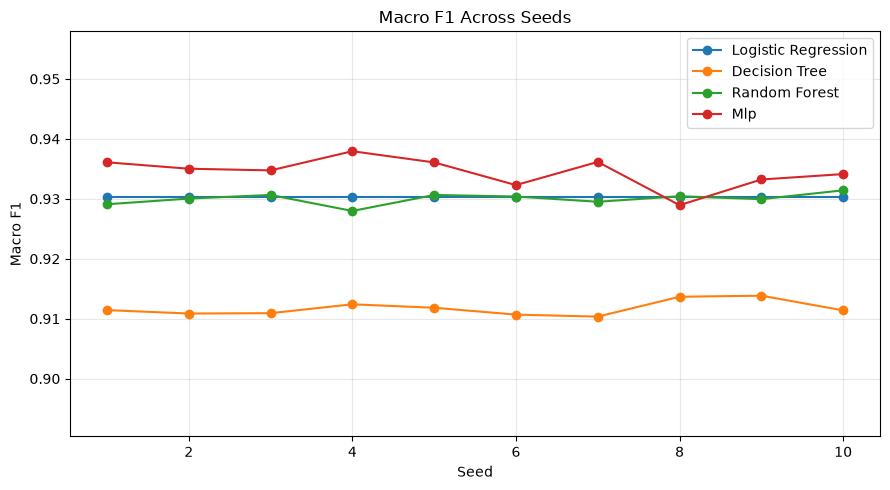

Saved: G:\Programming\xai\plots\04_model_evaluation\macro_f1_by_seed.png


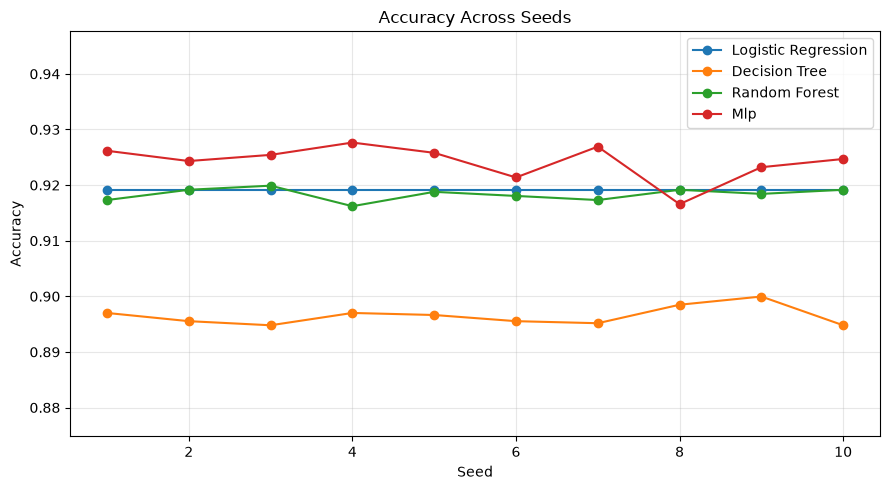

Saved: G:\Programming\xai\plots\04_model_evaluation\accuracy_by_seed.png


In [16]:
def plot_metric_by_seed(metrics_df: pd.DataFrame, metric: str, title: str, ylabel: str, output_path: Path):
    plt.figure(figsize=(9, 5))

    for model_name in MODEL_NAMES:
        model_metrics = metrics_df[metrics_df["model_name"] == model_name].sort_values("seed")

        if model_metrics.empty:
            continue

        plt.plot(
            model_metrics["seed"],
            model_metrics[metric],
            marker="o",
            label=model_name.replace("_", " ").title()
        )

    plt.title(title)
    plt.xlabel("Seed")
    plt.ylabel(ylabel)
    plt.ylim(
        max(0.0, metrics_df[metric].min() - 0.02),
        min(1.0, metrics_df[metric].max() + 0.02)
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")


plot_metric_by_seed(
    metrics_df=metrics_df,
    metric="f1_macro",
    title="Macro F1 Across Seeds",
    ylabel="Macro F1",
    output_path=PLOTS_DIR / "macro_f1_by_seed.png"
)

plot_metric_by_seed(
    metrics_df=metrics_df,
    metric="accuracy",
    title="Accuracy Across Seeds",
    ylabel="Accuracy",
    output_path=PLOTS_DIR / "accuracy_by_seed.png"
)

### Cell 16: Plot mean ± standard deviation performance

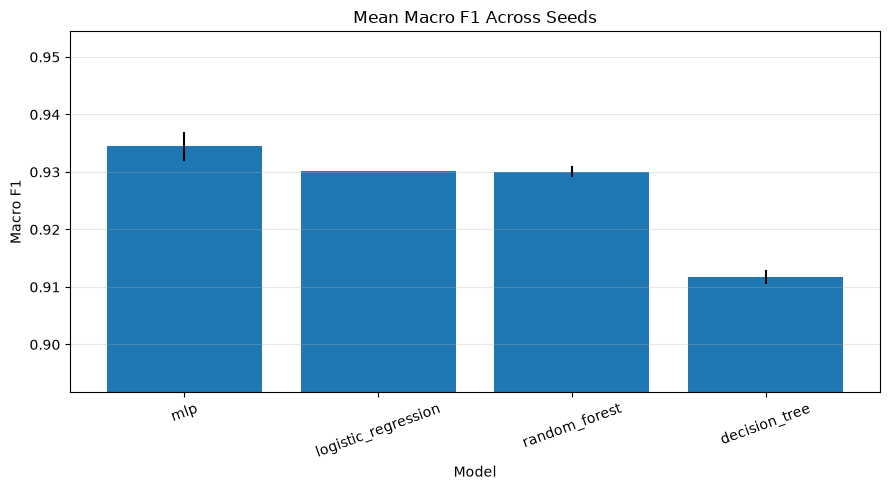

Saved: G:\Programming\xai\plots\04_model_evaluation\model_performance_mean_std_macro_f1.png


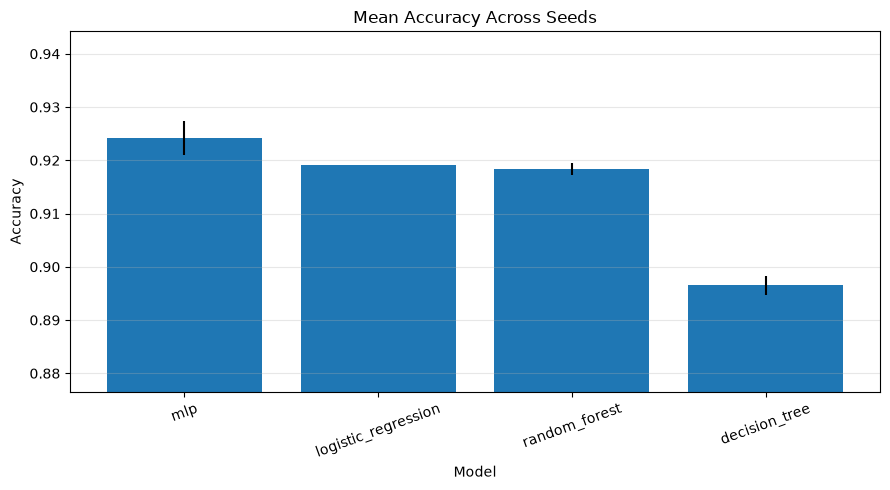

Saved: G:\Programming\xai\plots\04_model_evaluation\model_performance_mean_std_accuracy.png


In [17]:
def plot_mean_std_bar(summary_df: pd.DataFrame, mean_column: str, std_column: str, title: str, ylabel: str, output_path: Path):
    plot_df = summary_df.sort_values(mean_column, ascending=False)

    plt.figure(figsize=(9, 5))

    plt.bar(
        plot_df["model_name"],
        plot_df[mean_column],
        yerr=plot_df[std_column].fillna(0)
    )

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.ylim(
        max(0.0, plot_df[mean_column].min() - 0.02),
        min(1.0, plot_df[mean_column].max() + 0.02)
    )
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")


plot_mean_std_bar(
    summary_df=summary_df,
    mean_column="f1_macro_mean",
    std_column="f1_macro_std",
    title="Mean Macro F1 Across Seeds",
    ylabel="Macro F1",
    output_path=PLOTS_DIR / "model_performance_mean_std_macro_f1.png"
)

plot_mean_std_bar(
    summary_df=summary_df,
    mean_column="accuracy_mean",
    std_column="accuracy_std",
    title="Mean Accuracy Across Seeds",
    ylabel="Accuracy",
    output_path=PLOTS_DIR / "model_performance_mean_std_accuracy.png"
)

### Cell 17: Plot performance variability boxplots

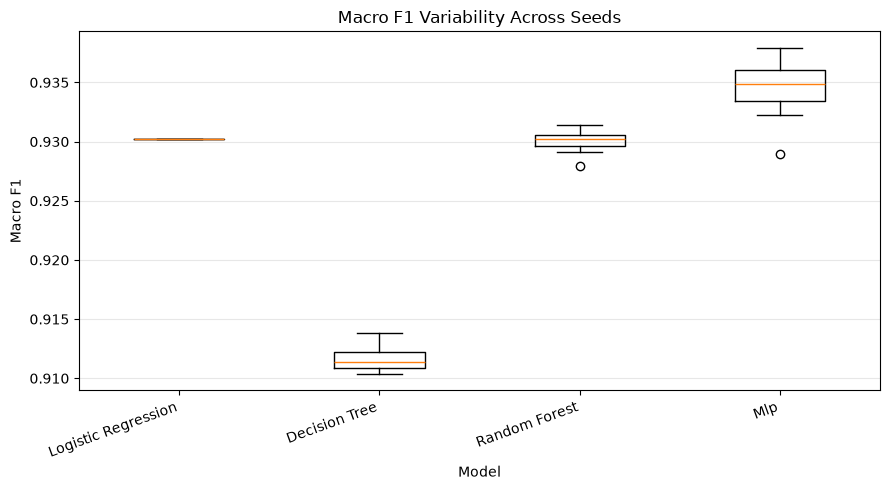

Saved: G:\Programming\xai\plots\04_model_evaluation\macro_f1_variability_boxplot.png


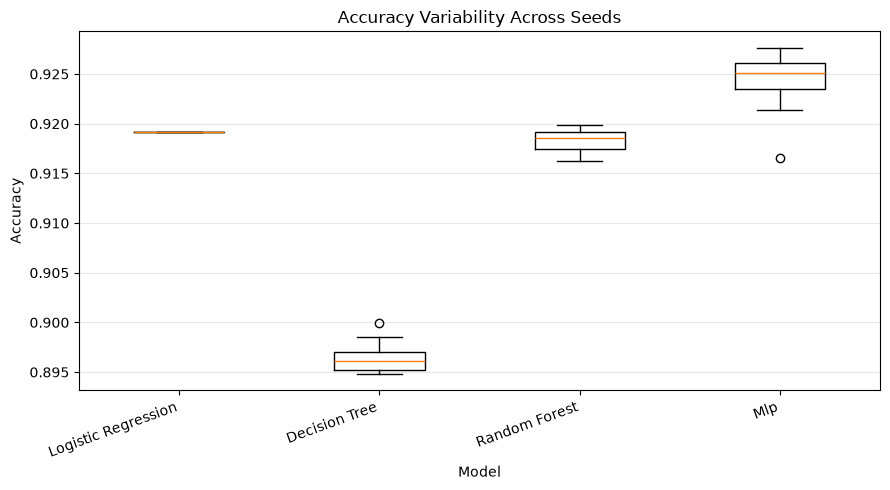

Saved: G:\Programming\xai\plots\04_model_evaluation\accuracy_variability_boxplot.png


In [21]:
def plot_metric_boxplot(metrics_df, metric, title, ylabel, output_path):
    preferred_model_order = [
        "logistic_regression",
        "decision_tree",
        "random_forest",
        "mlp"
    ]

    available_models = metrics_df["model_name"].dropna().unique().tolist()

    model_order = [
        model_name for model_name in preferred_model_order
        if model_name in available_models
    ]

    remaining_models = [
        model_name for model_name in available_models
        if model_name not in model_order
    ]

    model_order.extend(remaining_models)

    data = []
    labels = []

    for model_name in model_order:
        values = metrics_df.loc[
            metrics_df["model_name"] == model_name,
            metric
        ].dropna().astype(float).values

        if len(values) > 0:
            data.append(values)
            labels.append(model_name.replace("_", " ").title())

    if len(data) == 0:
        print(f"No data available for {metric}. Skipping plot.")
        return

    plt.figure(figsize=(9, 5))
    plt.boxplot(data)

    plt.xticks(
        ticks=range(1, len(labels) + 1),
        labels=labels,
        rotation=20,
        ha="right"
    )

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {output_path}")


plot_metric_boxplot(
    metrics_df=metrics_df,
    metric="f1_macro",
    title="Macro F1 Variability Across Seeds",
    ylabel="Macro F1",
    output_path=PLOTS_DIR / "macro_f1_variability_boxplot.png"
)

plot_metric_boxplot(
    metrics_df=metrics_df,
    metric="accuracy",
    title="Accuracy Variability Across Seeds",
    ylabel="Accuracy",
    output_path=PLOTS_DIR / "accuracy_variability_boxplot.png"
)

### Cell 18: Confusion pair analysis across seeds

In [22]:
confusion_pair_rows = []

for (seed, model_name), group_df in predictions_df.groupby(["seed", "model_name"]):
    cm = confusion_matrix(
        group_df["true_label"],
        group_df["predicted_label"],
        labels=class_labels
    )

    for true_index, true_label in enumerate(class_labels):
        for predicted_index, predicted_label in enumerate(class_labels):
            if true_label == predicted_label:
                continue

            count = int(cm[true_index, predicted_index])

            if count > 0:
                true_label_int = int(true_label)
                predicted_label_int = int(predicted_label)

                confusion_pair_rows.append({
                    "seed": int(seed),
                    "model_name": model_name,
                    "true_class_id": true_label_int,
                    "true_class_name": class_id_to_name[true_label_int],
                    "predicted_class_id": predicted_label_int,
                    "predicted_class_name": class_id_to_name[predicted_label_int],
                    "confusion_count": count
                })

confusion_pairs_df = pd.DataFrame(confusion_pair_rows)

confusion_pairs_path = EVALUATION_RESULTS_DIR / "top_confusion_pairs_all_seeds.csv"

if not confusion_pairs_df.empty:
    confusion_pairs_df = confusion_pairs_df.sort_values(
        by="confusion_count",
        ascending=False
    ).reset_index(drop=True)

    confusion_pairs_df.to_csv(confusion_pairs_path, index=False)

    confusion_pairs_summary_df = (
        confusion_pairs_df
        .groupby([
            "model_name",
            "true_class_id",
            "true_class_name",
            "predicted_class_id",
            "predicted_class_name"
        ])
        .agg(
            total_confusion_count=("confusion_count", "sum"),
            mean_confusion_count=("confusion_count", "mean"),
            std_confusion_count=("confusion_count", "std"),
            seeds_observed=("seed", "nunique")
        )
        .reset_index()
        .sort_values("total_confusion_count", ascending=False)
    )

else:
    confusion_pairs_df.to_csv(confusion_pairs_path, index=False)
    confusion_pairs_summary_df = pd.DataFrame()

confusion_pairs_summary_path = EVALUATION_RESULTS_DIR / "top_confusion_pairs_summary.csv"
confusion_pairs_summary_df.to_csv(confusion_pairs_summary_path, index=False)

print(f"Saved: {confusion_pairs_path}")
print(f"Saved: {confusion_pairs_summary_path}")

confusion_pairs_summary_df.head(15)


Saved: G:\Programming\xai\results\04_model_evaluation\top_confusion_pairs_all_seeds.csv
Saved: G:\Programming\xai\results\04_model_evaluation\top_confusion_pairs_summary.csv


,model_name,true_class_id,true_class_name,predicted_class_id,predicted_class_name,total_confusion_count,mean_confusion_count,std_confusion_count,seeds_observed
22,decision_tree,6,SIRA,3,DERMASON,615,61.5,2.953341,10
11,decision_tree,3,DERMASON,6,SIRA,603,60.3,3.622461,10
91,random_forest,6,SIRA,3,DERMASON,559,55.9,1.197219,10
33,logistic_regression,3,DERMASON,6,SIRA,530,53.0,0.000000,10
57,mlp,3,DERMASON,6,SIRA,467,46.7,8.832390,10
68,mlp,6,SIRA,3,DERMASON,437,43.7,10.478019,10
81,random_forest,3,DERMASON,6,SIRA,435,43.5,1.840894,10
43,logistic_regression,6,SIRA,3,DERMASON,410,41.0,0.000000,10
24,decision_tree,6,SIRA,5,SEKER,210,21.0,1.563472,10
25,logistic_regression,0,BARBUNYA,2,CALI,180,18.0,0.000000,10


### Cell 19: Plot top confusion pairs

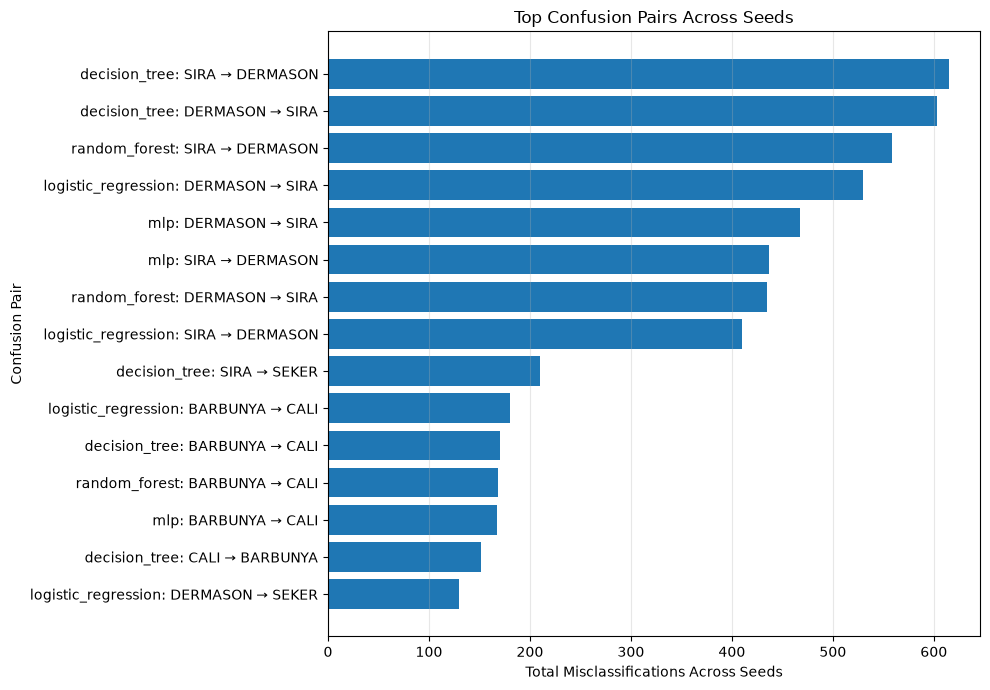

Saved: G:\Programming\xai\plots\04_model_evaluation\top_confusion_pairs_across_seeds.png


In [23]:
if confusion_pairs_summary_df.empty:
    print("No confusion pairs found. Skipping confusion pair plot.")

else:
    top_n = 15

    top_confusions = confusion_pairs_summary_df.head(top_n).copy()

    top_confusions["confusion_label"] = (
        top_confusions["model_name"]
        + ": "
        + top_confusions["true_class_name"]
        + " → "
        + top_confusions["predicted_class_name"]
    )

    top_confusions = top_confusions.sort_values(
        by="total_confusion_count",
        ascending=True
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_confusions["confusion_label"],
        top_confusions["total_confusion_count"]
    )

    plt.title("Top Confusion Pairs Across Seeds")
    plt.xlabel("Total Misclassifications Across Seeds")
    plt.ylabel("Confusion Pair")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plot_path = PLOTS_DIR / "top_confusion_pairs_across_seeds.png"

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {plot_path}")

### Cell 20: Aggregate confusion matrices across seeds

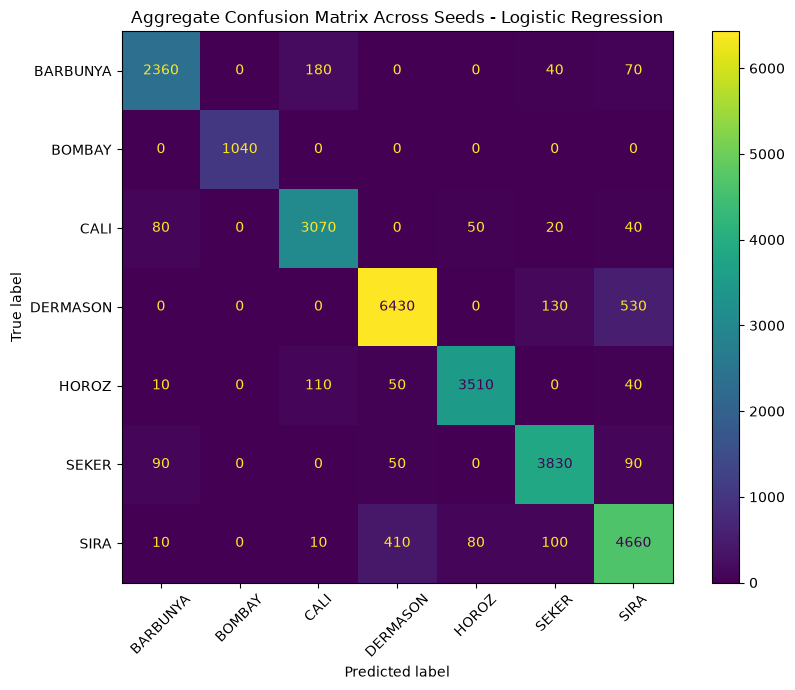

Saved: G:\Programming\xai\plots\04_model_evaluation\aggregate_confusion_matrix_all_seeds_logistic_regression.png


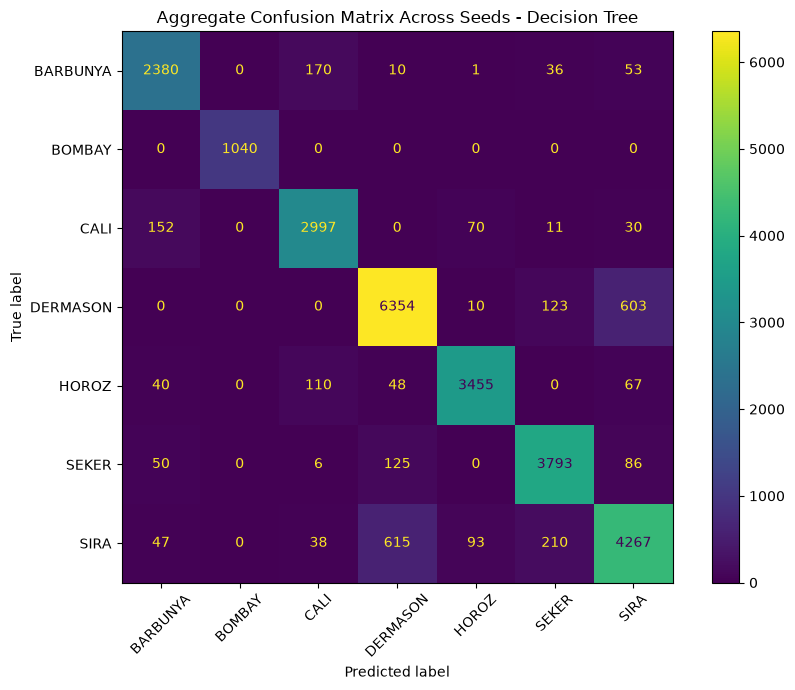

Saved: G:\Programming\xai\plots\04_model_evaluation\aggregate_confusion_matrix_all_seeds_decision_tree.png


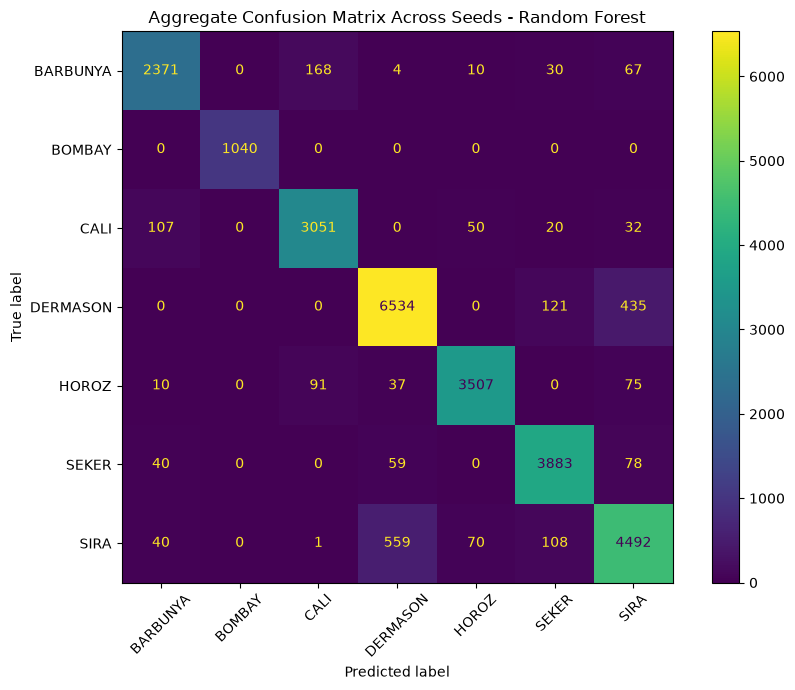

Saved: G:\Programming\xai\plots\04_model_evaluation\aggregate_confusion_matrix_all_seeds_random_forest.png


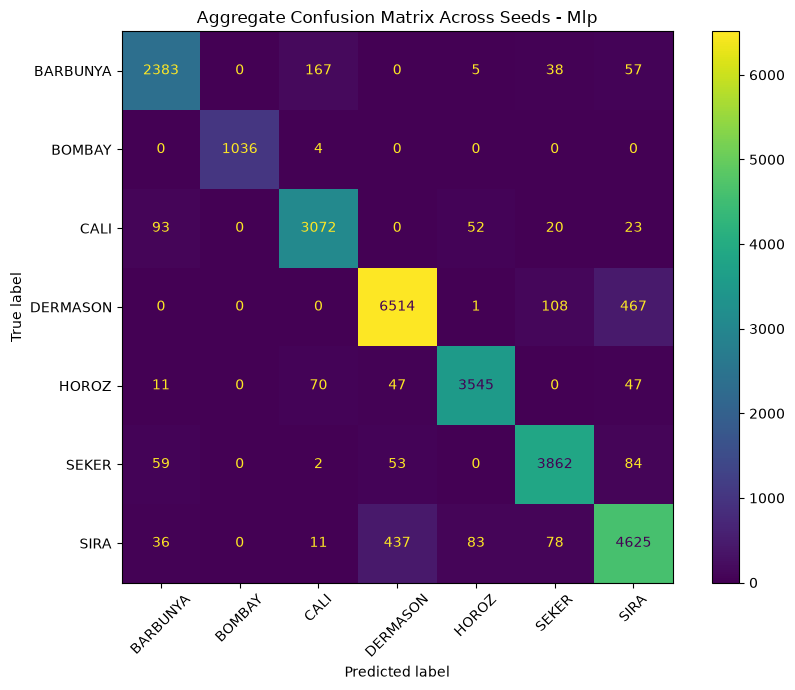

Saved: G:\Programming\xai\plots\04_model_evaluation\aggregate_confusion_matrix_all_seeds_mlp.png


In [24]:
def plot_aggregate_confusion_matrix(model_name: str, output_path: Path):
    model_predictions = predictions_df[predictions_df["model_name"] == model_name]

    matrix = confusion_matrix(
        model_predictions["true_label"],
        model_predictions["predicted_label"],
        labels=class_labels
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names
    )

    display.plot(
        values_format="d",
        ax=ax,
        xticks_rotation=45
    )

    ax.set_title(
        f"Aggregate Confusion Matrix Across Seeds - {model_name.replace('_', ' ').title()}"
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {output_path}")


for model_name in MODEL_NAMES:
    if model_name not in predictions_df["model_name"].unique():
        continue

    plot_aggregate_confusion_matrix(
        model_name=model_name,
        output_path=PLOTS_DIR / f"aggregate_confusion_matrix_all_seeds_{model_name}.png"
    )

### Cell 21: Save final seeded evaluation summary

In [25]:
def rounded(value, digits=6):
    if value is None:
        return None

    value = make_json_serializable(value)

    if isinstance(value, float):
        if math.isnan(value):
            return None

        return round(value, digits)

    return value


top_confusion_pair = None

if not confusion_pairs_summary_df.empty:
    first_confusion = confusion_pairs_summary_df.iloc[0]
    top_confusion_pair = {
        "model_name": first_confusion["model_name"],
        "true_class_name": first_confusion["true_class_name"],
        "predicted_class_name": first_confusion["predicted_class_name"],
        "total_confusion_count": int(first_confusion["total_confusion_count"])
    }


summary_records = make_json_serializable(summary_df)

evaluation_summary = {
    "project_stage": "04_model_evaluation",
    "experiment_type": "seeded_runs_fixed_train_test_split",
    "seeds": [int(seed) for seed in SEEDS],
    "primary_seed": int(PRIMARY_SEED),
    "models": [str(model_name) for model_name in MODEL_NAMES],
    "n_seed_model_runs": int(len(metrics_df)),
    "best_mean_accuracy_model": best_accuracy_model,
    "best_mean_macro_f1_model": best_f1_model,
    "most_stable_accuracy_model": most_stable_accuracy_model,
    "most_stable_macro_f1_model": most_stable_f1_model,
    "least_stable_macro_f1_model": least_stable_f1_model,
    "best_single_run": {
        "seed": int(best_single_run["seed"]),
        "model_name": best_single_run["model_name"],
        "accuracy": rounded(best_single_run["accuracy"]),
        "f1_macro": rounded(best_single_run["f1_macro"])
    },
    "top_confusion_pair": top_confusion_pair,
    "summary_mean_std": summary_records,
    "saved_outputs": {
        "evaluation_metrics_all_seeds": str(metrics_all_seeds_path),
        "evaluation_metrics_primary_seed": str(primary_metrics_path),
        "evaluation_summary_mean_std": str(summary_path),
        "classification_reports_all_seeds": str(reports_all_seeds_path),
        "classwise_performance_all_seeds": str(classwise_path),
        "classwise_performance_mean_std": str(classwise_summary_path),
        "confusion_matrices_all_seeds": str(confusion_matrices_path),
        "confusion_pairs_all_seeds": str(confusion_pairs_path),
        "confusion_pairs_summary": str(confusion_pairs_summary_path)
    },
    "main_interpretation": (
        "Use the mean metric values to compare average performance and the standard deviation "
        "values to discuss stability across random seeds. Lower standard deviation means the "
        "model is more stable across repeated seeded runs."
    )
}

evaluation_summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary_seeded.json"
legacy_evaluation_summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary.json"

save_json(evaluation_summary, evaluation_summary_path)
save_json(evaluation_summary, legacy_evaluation_summary_path)

print(f"Saved: {evaluation_summary_path}")
print(f"Saved legacy-compatible file: {legacy_evaluation_summary_path}")


Saved: G:\Programming\xai\results\04_model_evaluation\evaluation_summary_seeded.json
Saved legacy-compatible file: G:\Programming\xai\results\04_model_evaluation\evaluation_summary.json


### Cell 22: Final output checklist

In [26]:
print("Notebook 04 seeded evaluation completed.")
print()
print("Main saved tables:")
print(f"- {metrics_all_seeds_path}")
print(f"- {summary_path}")
print(f"- {primary_metrics_path}")
print(f"- {classwise_path}")
print(f"- {classwise_summary_path}")
print(f"- {confusion_pairs_path}")
print(f"- {confusion_pairs_summary_path}")
print()
print("Main saved JSON files:")
print(f"- {metrics_json_path}")
print(f"- {reports_all_seeds_path}")
print(f"- {confusion_matrices_path}")
print(f"- {evaluation_summary_path}")
print()
print("Main saved plots:")
print(f"- {PLOTS_DIR / 'macro_f1_by_seed.png'}")
print(f"- {PLOTS_DIR / 'accuracy_by_seed.png'}")
print(f"- {PLOTS_DIR / 'model_performance_mean_std_macro_f1.png'}")
print(f"- {PLOTS_DIR / 'model_performance_mean_std_accuracy.png'}")
print(f"- {PLOTS_DIR / 'macro_f1_variability_boxplot.png'}")
print(f"- {PLOTS_DIR / 'accuracy_variability_boxplot.png'}")
print(f"- {PLOTS_DIR / 'top_confusion_pairs_across_seeds.png'}")

Notebook 04 seeded evaluation completed.

Main saved tables:
- G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_all_seeds.csv
- G:\Programming\xai\results\04_model_evaluation\evaluation_summary_mean_std.csv
- G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_primary_seed.csv
- G:\Programming\xai\results\04_model_evaluation\classwise_performance_all_seeds.csv
- G:\Programming\xai\results\04_model_evaluation\classwise_performance_mean_std.csv
- G:\Programming\xai\results\04_model_evaluation\top_confusion_pairs_all_seeds.csv
- G:\Programming\xai\results\04_model_evaluation\top_confusion_pairs_summary.csv

Main saved JSON files:
- G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_all_seeds.json
- G:\Programming\xai\results\04_model_evaluation\classification_reports_all_seeds.json
- G:\Programming\xai\results\04_model_evaluation\confusion_matrices_all_seeds.json
- G:\Programming\xai\results\04_model_evaluation\evaluation_summary_seeded.json

